# Day 3 --- Supervised Learning: Predicting Heat Capacity (classical ML)

We predict the **heat capacity $C_p$** of an inorganic material from its
**chemical composition** and **temperature**, using classical machine-learning
models from `scikit-learn`.

This is the **same problem** we solve later with a neural network, so the two
results are directly comparable.

The pipeline never changes:

> **data → cleaning → split → features → scaling → models → evaluation**

*Based on Wang et al., "Machine Learning for Materials Scientists: An Introductory
Guide toward Best Practices," Chem. Mater. **32**, 4954 (2020).*

## Step 1 --- Setup

We import only what we need. `numpy`/`pandas` for data, `matplotlib` for plots,
`scipy.stats.norm` for the distribution figures, and `time` to measure how long
each model takes to fit.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from time import time

## Step 2 --- Load the dataset

The file `cp_data_demo.csv` has one row per measurement: a chemical **formula**,
a **temperature**, and the measured **heat capacity**. We rename the two long
column names to short ones.

In [2]:
cp_data = pd.read_csv('cp_data_demo.csv')

cp_data = cp_data.rename(columns={
    "CONDITION: Temperature (K)": "T (K)",
    "PROPERTY: Heat Capacity (J/mol K)": "Cp (J/molK)"})

cp_data.head()

,FORMULA,T (K),Cp (J/molK)
0,B2O3,1400.0,134.306
1,B2O3,1300.0,131.294
2,B2O3,1200.0,128.072
3,B2O3,1100.0,124.516
4,B2O3,1000.0,120.625


## Step 3 --- Look at the data

Always look before modelling. We check the size and peek at a few rows.

In [3]:
print('rows, columns:', cp_data.shape)
cp_data.head()

rows, columns: (4583, 3)


,FORMULA,T (K),Cp (J/molK)
0,B2O3,1400.0,134.306
1,B2O3,1300.0,131.294
2,B2O3,1200.0,128.072
3,B2O3,1100.0,124.516
4,B2O3,1000.0,120.625


In [4]:
# a small random sample, to see different compounds
RNG_SEED = 40
np.random.seed(RNG_SEED)

sample_rows = sorted(np.random.randint(cp_data.shape[0], size=10))
cp_data.iloc[sample_rows]

,FORMULA,T (K),Cp (J/molK)
443,B2Be3O6,1600.0,306.729
2103,Ca1S1,2300.0,59.115
2121,Ca1S1,500.0,50.501
3064,O1Ti1,400.0,44.978
3163,O3Ti2,2600.0,155.980
3340,O4V2,500.0,143.269
3398,Pb1,900.0,32.313
3603,F1Li1,0.0,70.549
3808,N1Zr1,3600.0,71.693
3889,Na2O2,2300.0,113.596


## Step 4 --- Clean the data

Two simple, physical checks:

1. drop rows with **missing values**;
2. **temperature and heat capacity cannot be negative** --- those rows are errors.

We print how many rows we remove at each step so nothing happens silently.

In [5]:
n_start = cp_data.shape[0]

# 1) drop missing values
cp_data = cp_data.dropna(axis=0, how='any')
print('removed (missing values):', n_start - cp_data.shape[0])

# 2) remove non-physical negative temperatures
n_before = cp_data.shape[0]
cp_data = cp_data.loc[cp_data['T (K)'] >= 0]
print('removed (negative T):     ', n_before - cp_data.shape[0])

# 3) remove non-physical negative heat capacities
n_before = cp_data.shape[0]
cp_data = cp_data.loc[cp_data['Cp (J/molK)'] >= 0]
print('removed (negative Cp):    ', n_before - cp_data.shape[0])

print('clean dataset:', cp_data.shape)

removed (missing values): 13
removed (negative T):      3
removed (negative Cp):     3
clean dataset: (4564, 3)


## Step 5 --- Split into train / validation / test (by formula!)

**The single most important step.** We do **not** split row by row. A compound can
appear at many temperatures; if some of its rows landed in *train* and others in
*test*, the model would have *already seen that compound* --- the test score would
be a lie (**data leakage**).

So we split on the **unique formulae**: every compound lives entirely in one set.

We use **70% train / 20% validation / 10% test**.

In [6]:
unique_formulae = cp_data['FORMULA'].unique()
print('unique formulae:', len(unique_formulae))

# shuffle the formulae reproducibly, then cut 70 / 20 / 10
np.random.seed(RNG_SEED)
shuffled = np.random.permutation(unique_formulae)

n_total = len(shuffled)
n_valid = int(round(0.20 * n_total))
n_test  = int(round(0.10 * n_total))
n_train = n_total - n_valid - n_test
print('formulae  train/valid/test:', n_train, n_valid, n_test)

train_formulae = shuffled[:n_train]
valid_formulae = shuffled[n_train:n_train + n_valid]
test_formulae  = shuffled[n_train + n_valid:]

unique formulae: 244
formulae  train/valid/test: 171 49 24


In [7]:
# select the rows belonging to each set of formulae
cp_train = cp_data.loc[cp_data['FORMULA'].isin(train_formulae)]
cp_valid = cp_data.loc[cp_data['FORMULA'].isin(valid_formulae)]
cp_test  = cp_data.loc[cp_data['FORMULA'].isin(test_formulae)]

print('rows  train/valid/test:', cp_train.shape[0], cp_valid.shape[0], cp_test.shape[0])

rows  train/valid/test: 3152 1011 401


In [8]:
# sanity check: no formula may appear in two sets at once
train_set = set(train_formulae)
valid_set = set(valid_formulae)
test_set  = set(test_formulae)

print('train ∩ valid:', len(train_set & valid_set))
print('train ∩ test :', len(train_set & test_set))
print('valid ∩ test :', len(valid_set & test_set))

train ∩ valid: 0
train ∩ test : 0
valid ∩ test : 0


## Step 6 --- Turn formulae into numbers (CBFV)

A model cannot read `"Al2O3"`. The **CBFV** package (Composition-Based Feature
Vector) turns each formula into a fixed-length vector of numbers built from
element properties (atomic weight, electronegativity, ...).

First we rename the columns to the names CBFV expects: `formula`, `T`, `target`.

In [9]:
rename_dict = {'FORMULA': 'formula', 'T (K)': 'T', 'Cp (J/molK)': 'target'}

cp_train = cp_train.rename(columns=rename_dict)
cp_valid = cp_valid.rename(columns=rename_dict)
cp_test  = cp_test.rename(columns=rename_dict)

cp_train.head()

,formula,T,target
0,B2O3,1400.0,134.306
1,B2O3,1300.0,131.294
2,B2O3,1200.0,128.072
3,B2O3,1100.0,124.516
4,B2O3,1000.0,120.625


**Path note.** CBFV is vendored inside the course folder. We add it to
`sys.path` so the import works regardless of where the notebook is launched from
(same fix used in the DNN notebook).

In [10]:
import sys
sys.path.append(os.path.abspath('../cbfv/cbfv'))
from composition import generate_features

`generate_features` returns, for each set: the feature matrix `X`, the
target vector `y`, the list of `formulae`, and any rows it had to skip.

In [11]:
X_train_unscaled, y_train, formulae_train, skipped_train = generate_features(
    cp_train, elem_prop='oliynyk',
    drop_duplicates=False, extend_features=True, sum_feat=True)

X_valid_unscaled, y_valid, formulae_valid, skipped_valid = generate_features(
    cp_valid, elem_prop='oliynyk',
    drop_duplicates=False, extend_features=True, sum_feat=True)

X_test_unscaled, y_test, formulae_test, skipped_test = generate_features(
    cp_test, elem_prop='oliynyk',
    drop_duplicates=False, extend_features=True, sum_feat=True)

print('feature columns:', X_train_unscaled.shape[1])
print('train/valid/test rows:',
      X_train_unscaled.shape[0], X_valid_unscaled.shape[0], X_test_unscaled.shape[0])

Processing Input Data: 100%|█████████████| 3152/3152 [00:00<00:00, 24703.59it/s]


	Featurizing Compositions...


Assigning Features...: 100%|█████████████| 3152/3152 [00:00<00:00, 14666.86it/s]


	Creating Pandas Objects...


Processing Input Data: 100%|█████████████| 1011/1011 [00:00<00:00, 17157.15it/s]


...

	Creating Pandas Objects...



Processing Input Data: 100%|███████████████| 401/401 [00:00<00:00, 24185.27it/s]


	Featurizing Compositions...


Assigning Features...: 100%|███████████████| 401/401 [00:00<00:00, 16439.73it/s]

	Creating Pandas Objects...
feature columns: 177
train/valid/test rows: 3152 1011 401


## Step 7 --- Scale and normalize (without leaking!)

Two transformations:

1. **StandardScaler** --- centre each feature to mean 0, std 1. The scaler *learns*
   the mean and std. **It must learn them from the training set only.** We then
   apply (`transform`) the *same* numbers to validation and test.
   Calling `fit_transform` on valid/test would leak their statistics into the
   pipeline --- a classic and silent mistake.
2. **Per-row L2 normalization** --- rescales each sample to unit length. This one is
   *stateless* (each row on its own), so applying it set by set is safe.

In [12]:
from sklearn.preprocessing import StandardScaler, normalize

scaler = StandardScaler()

# (1) fit the scaler ONLY on training data, then re-use it everywhere
X_train = scaler.fit_transform(X_train_unscaled)
X_valid = scaler.transform(X_valid_unscaled)   # transform, NOT fit_transform
X_test  = scaler.transform(X_test_unscaled)    # transform, NOT fit_transform

# (2) per-row normalization (stateless: safe to apply to each set)
X_train = normalize(X_train)
X_valid = normalize(X_valid)
X_test  = normalize(X_test)

print('shapes:', X_train.shape, X_valid.shape, X_test.shape)

shapes: (3152, 177) (1011, 177) (401, 177)


### What scaling does to the numbers

A quick before/after picture of one feature. Standardization moves a wide,
arbitrary-units distribution onto a comparable scale --- which is what
distance-based models (kNN, SVR) need to behave.

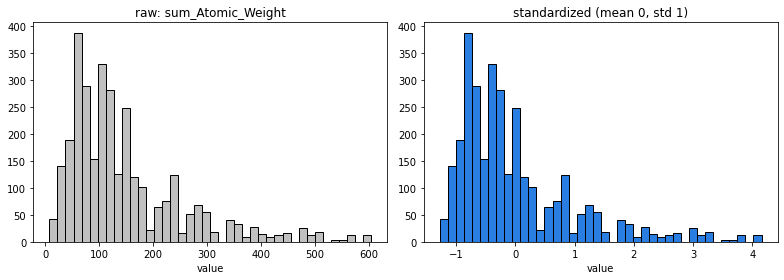

In [13]:
# pick one feature and compare its raw vs standardized distribution
feature_name = 'sum_Atomic_Weight'
raw_values = X_train_unscaled[feature_name].to_numpy()

# the standardized version of the SAME column (before per-row normalize)
std_column = StandardScaler().fit_transform(
    X_train_unscaled[[feature_name]]).ravel()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(raw_values, bins=40, color='silver', edgecolor='k')
ax[0].set_title('raw: ' + feature_name)
ax[0].set_xlabel('value')
ax[1].hist(std_column, bins=40, color='#2A7DE1', edgecolor='k')
ax[1].set_title('standardized (mean 0, std 1)')
ax[1].set_xlabel('value')
plt.tight_layout()
plt.show()

## Step 8 --- Nine regression models

We compare nine models, from a trivial baseline up to ensembles of trees:

- **DummyRegressor** --- predicts the mean. Our *floor*: any real model must beat it.
- **Ridge** --- linear regression with regularization.
- **KNeighborsRegressor** --- averages the *k* nearest neighbours.
- **SVR / LinearSVR** --- support-vector regression (curved kernel / straight & fast).
- **AdaBoost, GradientBoosting, ExtraTrees, RandomForest** --- ensembles of decision trees.

We keep them in a plain list of **classes** and instantiate each with `m()`.

In [14]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor

nine_methods = [DummyRegressor,
                Ridge,
                KNeighborsRegressor,
                SVR,
                LinearSVR,
                AdaBoostRegressor,
                GradientBoostingRegressor,
                ExtraTreesRegressor,
                RandomForestRegressor]

print('number of models:', len(nine_methods))

number of models: 9


## Step 9 --- Metrics and evaluation

Three numbers per model:

- **R²** --- fraction of variance explained (1.0 is perfect). *Careful:* R² depends on
  the spread of the set, so it is **not comparable across sets with different std**.
- **MAE** --- mean absolute error, in the same units as $C_p$. The honest, comparable one.
- **RMSE** --- root-mean-square error. Bigger than MAE when a few errors are large.

Note we compute RMSE as `sqrt(mean_squared_error(...))` --- `mean_squared_error`
alone returns the **squared** error, not the root.

In [15]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

def measure(actual, predicted):
    r2   = r2_score(actual, predicted)
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))   # RMSE = sqrt(MSE)
    return r2, mae, rmse

A small helper to draw a **parity plot** (predicted vs actual). Points on the
dashed diagonal are perfect predictions.

In [16]:
def plot_parity(actual, predicted, method):
    xy_max = np.max([np.max(actual), np.max(predicted)])

    # least-squares line through the points
    polyfit = np.polyfit(actual, predicted, deg=1)
    reg_line = np.poly1d(polyfit)

    xs = np.linspace(0, xy_max, 50)
    ys = reg_line(xs)

    plt.plot(actual, predicted, 'o', ms=8, mec='k', mfc='silver', alpha=0.4)
    plt.plot([0, xy_max], [0, xy_max], 'k--', label='perfect')
    plt.plot(xs, ys, 'r-', label='linear fit')

    plt.xlabel(r'Actual $C_p$', fontsize=13)
    plt.ylabel(r'Predicted $C_p$', fontsize=13)
    plt.legend(loc='upper left', fontsize=11)
    plt.title(method.__name__ +
              ',  R2 = {:0.4f}'.format(r2_score(actual, predicted)),
              fontsize=14)

The evaluation loop. For each model: fit on train, time it, predict on train
and validation, and store the three metrics. Plain `for` loop, plain lists.

In [17]:
def evaluate(X_train, y_train, X_valid, y_valid, methods):
    fit_time   = []
    meas_train = []
    meas_valid = []
    pred_valid = []

    for m in methods:
        model = m()

        start = time()
        model.fit(X_train, y_train)
        delta = time() - start
        print('{:26s} fitted in {:0.3f}s'.format(m.__name__, delta))

        y_pred_train = model.predict(X_train)
        y_pred_valid = model.predict(X_valid)

        fit_time.append(delta)
        pred_valid.append(y_pred_valid)
        meas_train.append(measure(y_train, y_pred_train))
        meas_valid.append(measure(y_valid, y_pred_valid))

    return meas_train, meas_valid, pred_valid, fit_time

In [18]:
results = evaluate(X_train, y_train, X_valid, y_valid, nine_methods)
meas_train, meas_valid, pred_valid, fit_time = results

DummyRegressor             fitted in 0.001s
Ridge                      fitted in 0.030s
KNeighborsRegressor        fitted in 0.001s
SVR                        fitted in 1.282s
LinearSVR                  fitted in 0.033s
AdaBoostRegressor          fitted in 5.943s
GradientBoostingRegressor  fitted in 14.453s
ExtraTreesRegressor        fitted in 8.930s
RandomForestRegressor      fitted in 36.716s


All nine parity plots on the validation set, in one grid.

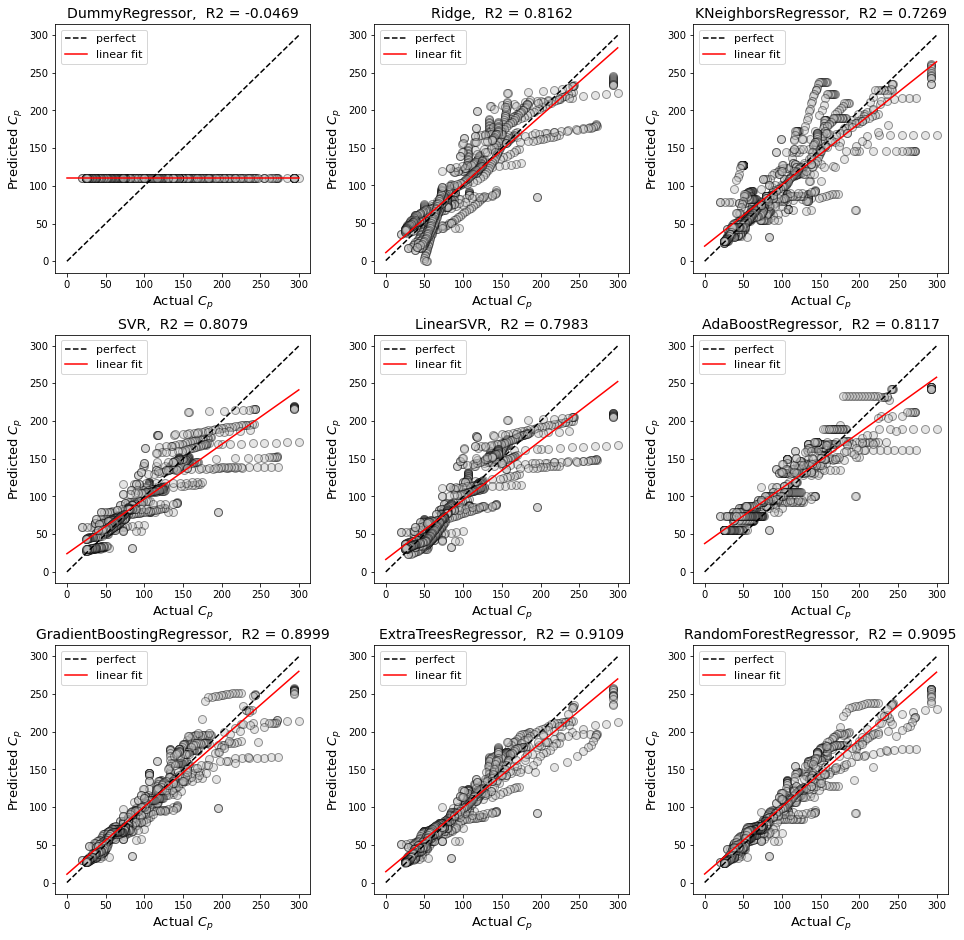

In [19]:
plt.figure(figsize=(16, 16))
plt.subplots_adjust(wspace=0.25, hspace=0.25)

for j in range(len(nine_methods)):
    plt.subplot(3, 3, j + 1)
    plot_parity(y_valid, pred_valid[j], nine_methods[j])

plt.savefig('nine_ML_methods.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 10 --- Performance table

Collect everything into one table and **sort by validation R²**. Building the index
with a plain `for` loop (no comprehensions).

In [20]:
# model names, one by one
model_names = []
for m in nine_methods:
    model_names.append(m.__name__)

df_time  = pd.DataFrame(fit_time, columns=['fit_time_s'], index=model_names)
df_train = pd.DataFrame(meas_train,
                        columns=['r2_train', 'mae_train', 'rmse_train'],
                        index=model_names)
df_valid = pd.DataFrame(meas_valid,
                        columns=['r2_valid', 'mae_valid', 'rmse_valid'],
                        index=model_names)

df = pd.concat([df_time, df_train, df_valid], axis=1)
###IMPORTANT###
df = df.sort_values('r2_valid', ascending=True)
###---------###
df

,fit_time_s,r2_train,mae_train,rmse_train,r2_valid,mae_valid,rmse_valid
DummyRegressor,0.001125,0.000000,49.298467,65.860921,-0.046886,50.540182,60.205849
KNeighborsRegressor,0.000602,0.993123,2.186682,5.461528,0.726883,19.249334,30.751315
LinearSVR,0.032969,0.752738,17.656693,32.749629,0.798297,16.363378,26.426832
SVR,1.281621,0.780063,16.114653,30.887116,0.807917,15.431200,25.788934
AdaBoostRegressor,5.942614,0.905858,17.116319,20.207858,0.811724,21.194296,25.532122
Ridge,0.029578,0.865877,15.383125,24.120127,0.816196,18.956855,25.227019
GradientBoostingRegressor,14.453387,0.982734,6.254410,8.654167,0.899920,12.193491,18.614977
RandomForestRegressor,36.715860,0.998707,1.000819,2.368319,0.909497,11.716822,17.701920
ExtraTreesRegressor,8.929714,0.999512,0.114775,1.454735,0.910880,11.178506,17.566102


Read the table by **MAE**, not only R². The tree ensembles (ExtraTrees,
GradientBoosting, RandomForest) should sit clearly above Ridge, kNN and the dummy
baseline.

## Step 11 --- A more honest number: grouped cross-validation

A single split gives a single number with **no error bar**. Re-shuffle the split and
the scores move. The honest way to report performance is **cross-validation**, and
because we must respect the no-leakage rule, we use **GroupKFold** with the formula
as the group: in every fold, a compound stays entirely on one side.

We pool train + validation for cross-validation and **leave test untouched** (look at
it only once, at the very end). The scaler is re-fitted *inside* every fold (via a
pipeline), so no statistics leak across folds.

In [21]:
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

# pool train + valid (UNSCALED: the pipeline scales inside each fold)
X_pool = pd.concat([X_train_unscaled, X_valid_unscaled], axis=0).to_numpy()
y_pool = np.concatenate([np.asarray(y_train), np.asarray(y_valid)])
groups = np.concatenate([np.asarray(formulae_train), np.asarray(formulae_valid)])

cv = GroupKFold(n_splits=5)

# evaluate every model with the same folds; collect mean and std of R2
cv_names = []
cv_means = []
cv_stds  = []

for m in nine_methods:
    pipe = make_pipeline(StandardScaler(), Normalizer(), m())
    scores = cross_validate(pipe, X_pool, y_pool, groups=groups,
                            cv=cv, scoring='r2', n_jobs=-1)['test_score']
    cv_names.append(m.__name__)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_table = pd.DataFrame({'r2_mean': cv_means, 'r2_std': cv_stds},
                        index=cv_names)
cv_table = cv_table.sort_values('r2_mean', ascending=False)
cv_table

,r2_mean,r2_std
ExtraTreesRegressor,0.897208,0.011173
GradientBoostingRegressor,0.885658,0.018956
RandomForestRegressor,0.854417,0.036499
AdaBoostRegressor,0.814463,0.033328
Ridge,0.798707,0.032870
SVR,0.751660,0.055889
LinearSVR,0.733958,0.059552
KNeighborsRegressor,0.714283,0.036212
DummyRegressor,-0.022899,0.018715


Now each model has a **mean ± std** --- a result *with an error bar*. If two
models are within one std of each other, the data cannot tell them apart.

## Step 12 --- The test set, exactly once

Pick the **best model by validation** (typically a tree ensemble), retrain on
train + validation, and report on the held-out test set --- the number you would
quote in a paper.

In [22]:
# choose the best model by validation R2 (top of the sorted CV table)
best_name = cv_table.index[0]

best_class = None
for m in nine_methods:
    if m.__name__ == best_name:
        best_class = m
print('best model by CV:', best_name)

# retrain on train + valid, evaluate on test (scale: fit on the train+valid pool)
X_fit_unscaled = pd.concat([X_train_unscaled, X_valid_unscaled], axis=0)
y_fit = np.concatenate([np.asarray(y_train), np.asarray(y_valid)])

final_scaler = StandardScaler()
X_fit  = normalize(final_scaler.fit_transform(X_fit_unscaled))
X_test_final = normalize(final_scaler.transform(X_test_unscaled))

best_model = best_class()
best_model.fit(X_fit, y_fit)
y_pred_test = best_model.predict(X_test_final)

r2_t, mae_t, rmse_t = measure(y_test, y_pred_test)
print('TEST  R2  = {:0.4f}'.format(r2_t))
print('TEST  MAE = {:0.4f}'.format(mae_t))
print('TEST  RMSE= {:0.4f}'.format(rmse_t))

best model by CV: ExtraTreesRegressor
TEST  R2  = 0.9762
TEST  MAE = 8.5132
TEST  RMSE= 13.6334


## Exercises

1. **Seed variance.** Change `RNG_SEED` to a few different values and re-run the
   split. How much does the **test R²** move? (A swing of ~0.04 is pure chance, not
   a better model.)

2. **MAE vs R².** Sort the table by `mae_valid` instead of `r2_valid`. Does the
   ranking change? Which metric do you trust to compare models, and why?

3. **Remove the per-row `normalize`.** Re-run and watch the distance-based models
   (kNN, SVR). Does removing it hurt? By how much?

4. **The leakage experiment (do it *wrong* on purpose).** Replace
   `scaler.transform` on valid/test with `scaler.fit_transform`. The score will go
   *up* --- and it will be a lie. Explain in one sentence why.

5. **Classical vs deep learning.** Compare your best classical model here with the
   neural network from the DNN notebook (test R² ≈ 0.87). Does deep learning beat a
   tuned tree ensemble on this tabular data?